<a href="https://colab.research.google.com/github/prometricas/Pascuas_Canad-/blob/main/Merino_Canada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Instalación de librerías**

In [1]:
# Prophet (Meta) — se instala desde PyPI directamente
!pip install prophet --quiet

# LightGBM para el modelo de ML
!pip install lightgbm --quiet

# Openpyxl para leer el Excel
!pip install openpyxl --quiet

# Verificación de versiones
import prophet
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib
import sklearn

print("✅ Librerías cargadas correctamente")
print(f"   prophet     : {prophet.__version__}")
print(f"   lightgbm    : {lgb.__version__}")
print(f"   pandas      : {pd.__version__}")
print(f"   numpy       : {np.__version__}")
print(f"   matplotlib  : {matplotlib.__version__}")
print(f"   scikit-learn: {sklearn.__version__}")

✅ Librerías cargadas correctamente
   prophet     : 1.3.0
   lightgbm    : 4.6.0
   pandas      : 2.2.2
   numpy       : 2.0.2
   matplotlib  : 3.10.0
   scikit-learn: 1.6.1


# **2. Carga de datos**
* Carga el Excel, convierte fechas, filtra las dos categorías merino.
* Genera una serie diaria completa rellenando con ceros los días sin ventas.
* Imprime estadísticas clave de cada serie.
* Grafica ambas con líneas verticales rojas en los dos Black Fridays históricos para que confirmes visualmente que el patrón está bien identificado.

Saving data_ventas_category.xlsx to data_ventas_category (1).xlsx
Archivo "data_ventas_category (1).xlsx" subido.
Shape total: (18477, 8)
Categorías: ['MENS SUPPORTIVE TIGHT' 'WOMENS SUPPORTIVE TIGHT' 'MENS SUPPORTIVE SHORT'
 'WOMENS SUPPORTIVE SHORT' 'MENS MERINO SUPPORTIVE TIGHT'
 'WOMENS MERINO SUPPORTIVE TIGHT' 'Socks']
Rango de fechas: 2024-01-01 → 2026-01-31

MENS MERINO SUPPORTIVE TIGHT
  Fechas: 2024-10-29 → 2026-01-31
  Días con ventas > 0: 272 de 460
  Total vendido: 8,929
  Pico máximo:   469 el 2025-11-28

WOMENS MERINO SUPPORTIVE TIGHT
  Fechas: 2024-10-30 → 2026-01-31
  Días con ventas > 0: 217 de 459
  Total vendido: 2,254
  Pico máximo:   173 el 2025-11-28


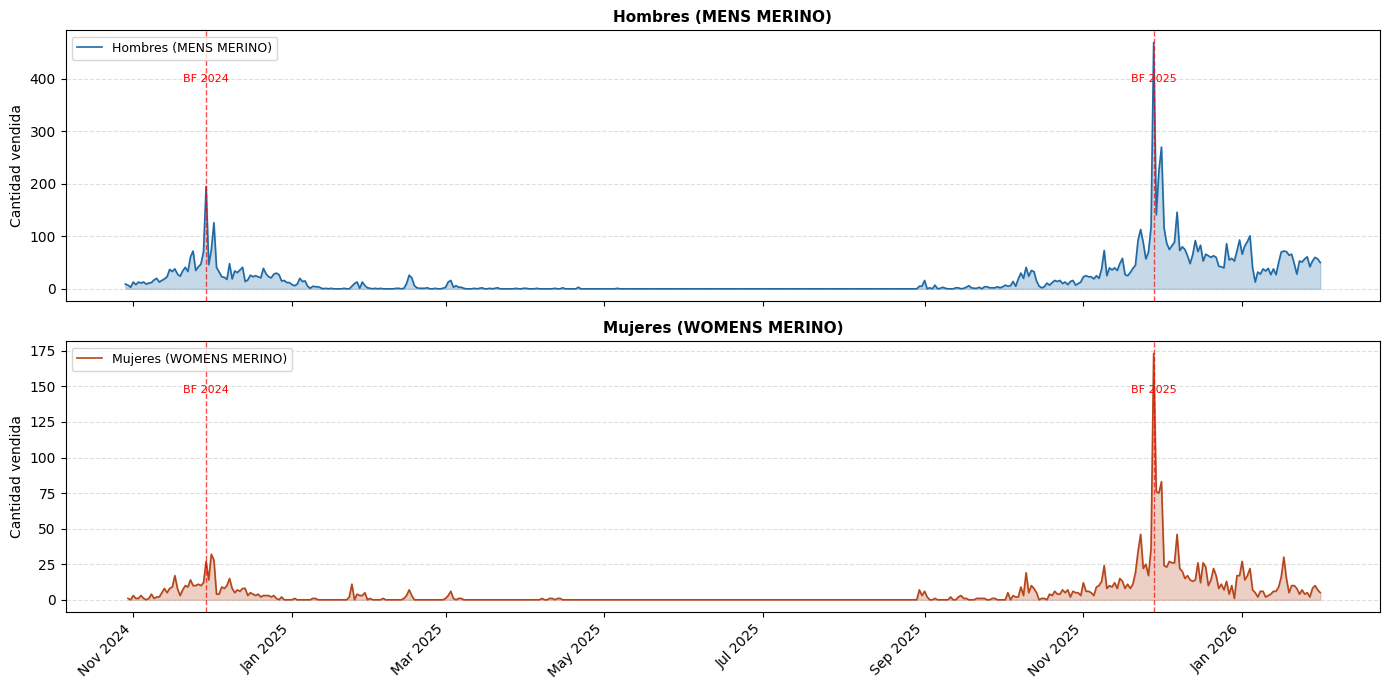

✅ Gráfico guardado como series_merino.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files
import io # Import io for BytesIO

# --- 1. Carga ---
uploaded = files.upload()
# Assuming only one file is uploaded, get its content
for fn in uploaded.keys():
  print(f'Archivo "{fn}" subido.')
  file_content = uploaded[fn]
  break # Process only the first uploaded file

# Pass the BytesIO object to pd.read_excel
df = pd.read_excel(io.BytesIO(file_content))
df["Date"] = pd.to_datetime(df["Date"])

print(f"Shape total: {df.shape}")
print(f"Categorías: {df['Product category'].dropna().unique()}")
print(f"Rango de fechas: {df['Date'].min().date()} → {df['Date'].max().date()}")

# --- 2. Filtrar y agregar por día ---
CATS = ["MENS MERINO SUPPORTIVE TIGHT", "WOMENS MERINO SUPPORTIVE TIGHT"]

series = {}
for cat in CATS:
    daily = (
        df[df["Product category"] == cat]
        .groupby("Date")["Quantity"]
        .sum()
        .reset_index()
        .rename(columns={"Quantity": "y"})
    )
    # Rellenar días sin ventas con 0
    full_range = pd.date_range(daily["Date"].min(), daily["Date"].max(), freq="D")
    daily = daily.set_index("Date").reindex(full_range, fill_value=0).reset_index()
    daily.columns = ["ds", "y"]
    series[cat] = daily
    print(f"\n{cat}")
    print(f"  Fechas: {daily['ds'].min().date()} → {daily['ds'].max().date()}")
    print(f"  Días con ventas > 0: {(daily['y'] > 0).sum()} de {len(daily)}")
    print(f"  Total vendido: {daily['y'].sum():,}")
    print(f"  Pico máximo:   {daily['y'].max()} el {daily.loc[daily['y'].idxmax(), 'ds'].date()}")

# --- 3. Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
colors = ["#1f6aa5", "#b5451b"]
labels = ["Hombres (MENS MERINO)", "Mujeres (WOMENS MERINO)"]

for ax, cat, color, label in zip(axes, CATS, colors, labels):
    s = series[cat]
    ax.fill_between(s["ds"], s["y"], alpha=0.25, color=color)
    ax.plot(s["ds"], s["y"], color=color, linewidth=1.2, label=label)

    # Marcar Black Fridays
    for bf_date, bf_label in [("2024-11-29", "BF 2024"), ("2025-11-28", "BF 2025")]:
        ax.axvline(pd.Timestamp(bf_date), color="red", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(pd.Timestamp(bf_date), ax.get_ylim()[1]*0.8, bf_label,
                color="red", fontsize=8, ha="center")

    ax.set_ylabel("Cantidad vendida", fontsize=10)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("series_merino.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado como series_merino.png")

# **3. Feature engineering y calendario de eventos**
* Calcula el **Black Friday** exacto para cualquier año (4° jueves de noviembre), incluyendo 2026.
* Construye el calendario de eventos que _Prophet_ necesita, con ventanas asimétricas: por ejemplo, Black Friday tiene rampa de 10 días antes y cola de 2 días después, capturando el comportamiento real que se ve en las gráficas.
* Genera el bloque de _features_ para LightGBM: calendario, proximidad al BF en días (variable continua, muy poderosa), indicadores de ventanas clave, términos de Fourier para la curva anual suave, y lags/medias móviles para el patrón semanal.

In [4]:
# --- 1. Función para calcular Black Friday (4° jueves de noviembre) ---
def get_black_friday(year):
    """Devuelve la fecha del Black Friday (4° jueves de noviembre) para un año dado."""
    nov1 = pd.Timestamp(f"{year}-11-01")
    # Día de la semana: lunes=0 ... jueves=3
    days_to_thursday = (3 - nov1.dayofweek) % 7
    first_thursday = nov1 + pd.Timedelta(days=days_to_thursday)
    return first_thursday + pd.Timedelta(weeks=3)  # 4° jueves

for yr in [2024, 2025, 2026]:
    print(f"Black Friday {yr}: {get_black_friday(yr).date()}")

# --- 2. Calendario de eventos especiales para Prophet ---
def build_events(years):
    rows = []
    for yr in years:
        bf = get_black_friday(yr)
        events = {
            # Black Friday: ventana asimétrica (rampa 10 días antes, cola 2 días después)
            "black_friday":      (bf, -10, 2),
            # Cyber Monday (lunes siguiente al BF)
            "cyber_monday":      (bf + pd.Timedelta(days=3), -1, 3),
            # Segunda ola diciembre (aprox. 7-10 dic)
            "dic_second_wave":   (pd.Timestamp(f"{yr}-12-08"), -2, 5),
            # Navidad / fin de año
            "christmas":         (pd.Timestamp(f"{yr}-12-25"), -4, 3),
        }
        for name, (date, lower, upper) in events.items():
            rows.append({"holiday": name, "ds": date,
                         "lower_window": lower, "upper_window": upper})
    return pd.DataFrame(rows)

holidays_df = build_events([2024, 2025, 2026])
print("\nCalendario de eventos:")
print(holidays_df.to_string(index=False))

# --- 3. Feature engineering para el modelo LightGBM ---
def build_features(daily_series):
    """
    Recibe un DataFrame con columnas [ds, y] y agrega features de calendario,
    lags y medias móviles.
    """
    s = daily_series.copy()
    s = s.sort_values("ds").reset_index(drop=True)

    # --- Calendario básico ---
    s["dayofweek"]   = s["ds"].dt.dayofweek        # 0=lun … 6=dom
    s["month"]       = s["ds"].dt.month
    s["dayofyear"]   = s["ds"].dt.dayofyear
    s["weekofyear"]  = s["ds"].dt.isocalendar().week.astype(int)
    s["is_weekend"]  = (s["dayofweek"] >= 5).astype(int)

    # --- Proximidad a Black Friday (días relativos al BF de ese año) ---
    def days_to_bf(date):
        bf = get_black_friday(date.year)
        delta = (date - bf).days

Black Friday 2024: 2024-11-28
Black Friday 2025: 2025-11-27
Black Friday 2026: 2026-11-26

Calendario de eventos:
        holiday         ds  lower_window  upper_window
   black_friday 2024-11-28           -10             2
   cyber_monday 2024-12-01            -1             3
dic_second_wave 2024-12-08            -2             5
      christmas 2024-12-25            -4             3
   black_friday 2025-11-27           -10             2
   cyber_monday 2025-11-30            -1             3
dic_second_wave 2025-12-08            -2             5
      christmas 2025-12-25            -4             3
   black_friday 2026-11-26           -10             2
   cyber_monday 2026-11-29            -1             3
dic_second_wave 2026-12-08            -2             5
      christmas 2026-12-25            -4             3
